In [1]:
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "sst2"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating test split: 100%|██████████| 1821/1821 [00:00<00:00, 1533700.32 examples/s]


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['sentence', 'label', 'idx'],
    num_rows: 67349
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence': 'hide new secretions from the parental units ',
 'label': 0,
 'idx': 0}

In [10]:
raw_train_dataset[5]['sentence']

"that 's far too tragic to merit such superficial treatment "

In [11]:
raw_train_dataset[5]['label']

0

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'sentence': Value('string'),
 'label': ClassLabel(names=['negative', 'positive']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["sentence"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

Map: 100%|██████████| 1821/1821 [00:00<00:00, 73313.06 examples/s]


DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1821
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 47]),
 'token_type_ids': torch.Size([32, 47]),
 'attention_mask': torch.Size([32, 47])}

# 4. Loading model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.7323, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [25]:
device = torch.device("cuda:1") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

device

device(type='cuda', index=1)

In [26]:
from train_eval_func import eval_loop

In [27]:
eval_loop(model, val_dataloader, task_name, device)

({'accuracy': 0.4896788990825688}, 0.8061415680817196)

# 5. Learning Rate and Leanring Scheduler Setup

In [28]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=3e-5)

In [29]:
from train_eval_func import set_lr_scheduler

num_epochs = 3
num_training_steps = num_epochs * len(train_dataloader)

lr_scheduler = set_lr_scheduler(
    optimizer          = optimizer,
    num_training_steps = num_training_steps
)

print(num_training_steps)

6315


In [30]:
patience=3
save_path=f'./weights/bert-{task_name}.pt'

# 6. Training

In [31]:
from train_eval_func import train

In [32]:
train_stats = train(
    model,
    train_dataloader,
    val_dataloader,
    task_name,
    device,
    num_epochs=num_epochs,
    lr=lr_scheduler,
    patience=patience,
    use_early_stopping=True,
    optimizer=optimizer,
    lr_scheduler=lr_scheduler,
    save_path=save_path,
    display_epoch_iter=True
)

Training:   0%|          | 0/6315 [00:00<?, ?it/s]/home/abhinavl/work/Layer_Graft/layer-grafting-publication/glue_fine_tune/../train_eval_func.py:188: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  total_loss += float(loss)
Training:  33%|███▎      | 2105/6315 [02:31<04:19, 16.21it/s]

✓ Saved checkpoint (best loss: 0.2309)

<----------------- Epoch 1 ----------------->
Loss: 0.21, Training Metrics:
  accuracy: 0.9208
Validation Loss: 0.23, Validation Metrics:
  accuracy: 0.9220
Elapsed Time: 139.4993 sec


Training:  67%|██████▋   | 4209/6315 [04:47<02:18, 15.24it/s]  


<----------------- Epoch 2 ----------------->
Loss: 0.12, Training Metrics:
  accuracy: 0.9662
Validation Loss: 0.31, Validation Metrics:
  accuracy: 0.9255
Elapsed Time: 137.1723 sec


Training: 100%|██████████| 6315/6315 [07:06<00:00, 14.79it/s]


<----------------- Epoch 3 ----------------->
Loss: 0.1, Training Metrics:
  accuracy: 0.9806
Validation Loss: 0.42, Validation Metrics:
  accuracy: 0.9312
Elapsed Time: 138.2499 sec

Total Training Time: 426.93 sec
Best validation loss: 0.2309


### Plotting Loss

In [33]:
from train_eval_func import plotLoss, plotAccuracy

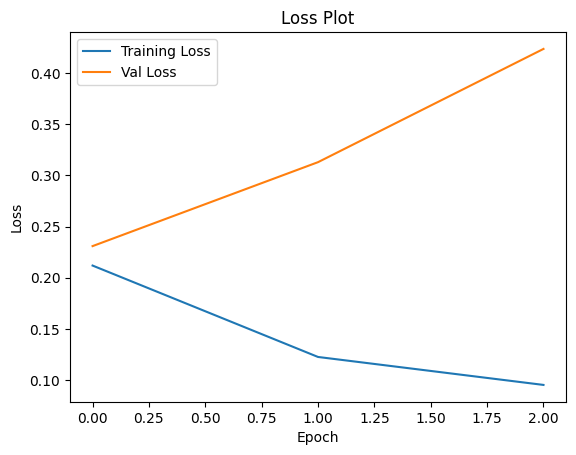

In [34]:
plotLoss(train_stats['train_losses'], train_stats['val_losses'], title="Loss Plot")

### Plotting Accuracy

In [35]:
def getMetricList(train_stats, metric_name='accuracy'):
    train_values = [m[metric_name] for m in train_stats['train_metrics_history']]
    val_values = [m[metric_name] for m in train_stats['val_metrics_history']]

    return train_values, val_values

In [36]:
train_values, val_values = getMetricList(train_stats)

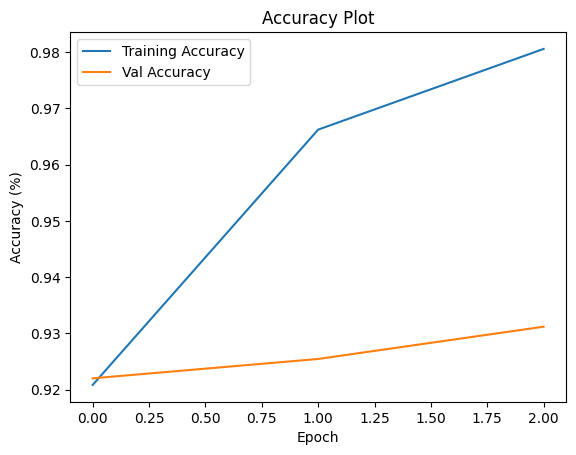

In [37]:
plotAccuracy(train_values, val_values, title="Accuracy Plot")

# 7. Evaluation

In [38]:
best_weight = torch.load(save_path)

In [39]:
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [40]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.9220183486238532}